# Comparaison Heston (1993) / HN (2000) / CHJ (2009) — Analyse des résultats

Trois modèles de pricing d'options par inversion de Fourier de la fonction
caractéristique sont calibrés sur les chaînes d'options AAPL à trois dates
représentant trois régimes de volatilité (calm / normal / stressed). Pour
chaque calibration, on mesure la qualité du fit in-sample et la performance
prédictive à 1 jour et 5 jours.

**Ce notebook lit les parquets pré-calculés par `scripts/run_batch.py`.** Pas
de calibration ici, juste de la lecture, des plots et de l'interprétation.


## 1. Setup — ce qu'on a calibré

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Couleurs / noms standardisés
MODEL_COLORS = {'heston93': '#1f77b4', 'hn2000': '#ff7f0e', 'chj2009': '#2ca02c'}
MODEL_NAMES  = {'heston93': 'Heston 93', 'hn2000': 'HN 00', 'chj2009': 'CHJ 09'}
REGIME_ORDER = ['calm', 'normal', 'stressed']
MODELS = ['heston93', 'hn2000', 'chj2009']

# Config + mapping secteurs (driven par config.yaml)
from src.config import load_config
from src.analysis import attach_sector, sectors_present, sector_coverage, tickers_in_sector
cfg = load_config('../config.yaml')
SECTOR_MAP = cfg.sectors
print(f'Secteurs déclarés : {list(SECTOR_MAP)}')

# Chargement des résultats
metrics = pd.read_parquet('../results/batch_results.parquet')
metrics['date'] = pd.to_datetime(metrics['date'])

# Attache la colonne 'sector' (data-driven, zero hardcoding)
metrics = attach_sector(metrics, SECTOR_MAP)

# Récap de couverture
print('\nCouverture sectorielle :')
print(sector_coverage(metrics, SECTOR_MAP).to_string(index=False))
print()

# Tableau récap des calibrations
recap = metrics[['date', 'ticker', 'sector', 'model', 'regime', 'n_options',
                  'in_sample_iv_vega_rmse', 'oos_iv_vega_rmse_J1',
                  'oos_iv_vega_rmse_J5', 'calibration_time_sec']].copy()
recap['date'] = recap['date'].dt.date
recap.round(3)

Secteurs déclarés : ['Tech', 'Financials', 'Energy']

Couverture sectorielle :
    sector  n_declared  n_calibrated    tickers
      Tech           3             2 AAPL, MSFT
Financials           2             2    GS, JPM
    Energy           2             2   CVX, XOM



,date,ticker,sector,model,regime,n_options,in_sample_iv_vega_rmse,oos_iv_vega_rmse_J1,oos_iv_vega_rmse_J5,calibration_time_sec
0,2025-02-03,AAPL,Tech,heston93,calm,324,0.694,0.832,0.823,7.804
1,2025-02-03,AAPL,Tech,hn2000,calm,376,0.935,1.021,1.020,101.296
2,2025-02-03,AAPL,Tech,chj2009,calm,376,0.878,1.043,1.042,72.671
3,2025-06-02,AAPL,Tech,heston93,normal,292,0.644,0.661,0.710,9.196
4,2025-06-02,AAPL,Tech,hn2000,normal,292,0.668,0.669,0.734,69.888
5,2025-06-02,AAPL,Tech,chj2009,normal,292,0.661,0.652,0.724,19.540
6,2026-01-02,AAPL,Tech,heston93,stressed,354,0.876,0.888,1.026,4.319
7,2026-01-02,AAPL,Tech,hn2000,stressed,354,0.925,0.906,0.907,78.780
8,2026-01-02,AAPL,Tech,chj2009,stressed,354,0.898,0.901,1.035,22.304
9,2025-02-03,MSFT,Tech,heston93,calm,487,1.706,1.636,1.686,6.097


### Contexte volatilité — justification des régimes

Vol réalisée 21j moyenne des 6 tickers (proxy de la VIX). Les bandes
verticales matérialisent les 3 mois de test choisis dans `config.yaml`.

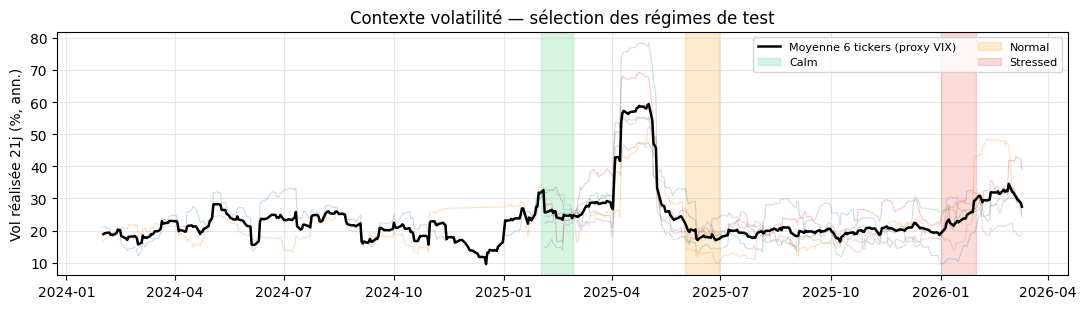

In [2]:
from src.preprocessing import load_spot_history

# Vol réalisée 21j par ticker, puis moyenne (proxy VIX)
rv_per_ticker = {}
for t in cfg.tickers:
    try:
        h = load_spot_history(t, cfg.data_root)
    except Exception:
        continue
    if h.empty: continue
    rv = h.set_index('trade_date')['log_return'].rolling(21).std() * np.sqrt(252) * 100
    rv_per_ticker[t] = rv

rv_avg = pd.concat(rv_per_ticker, axis=1).mean(axis=1)

REGIME_COLORS = {'calm': '#2ecc71', 'normal': '#f39c12', 'stressed': '#e74c3c'}

fig, ax = plt.subplots(figsize=(11, 3.2))
# Tickers individuels (transparence basse)
for t, rv in rv_per_ticker.items():
    ax.plot(rv.index, rv.values, alpha=0.25, linewidth=0.8)
# Moyenne en noir
ax.plot(rv_avg.index, rv_avg.values, color='black', linewidth=1.8,
        label='Moyenne 6 tickers (proxy VIX)')

# Bandes verticales pour les 3 mois de test
labels_done = set()
for regime, dates_list in cfg.oos['test_months'].items():
    for d in dates_list:
        d = pd.Timestamp(d)
        end = d + pd.offsets.MonthEnd(0)
        lbl = regime.capitalize() if regime not in labels_done else None
        ax.axvspan(d, end, alpha=0.20, color=REGIME_COLORS.get(regime, 'gray'),
                   label=lbl)
        labels_done.add(regime)

ax.set_ylabel('Vol réalisée 21j (%, ann.)')
ax.set_title('Contexte volatilité — sélection des régimes de test')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('../results/figures/00_vol_context.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Comparaison globale in-sample

**Question.** À chaque date de calibration, quel modèle minimise le mieux la
loss IV-vega RMSE sur le panel d'options ?

**Lecture.** Plus la barre est basse, mieux le modèle fitte. On compare les
3 modèles côte à côte dans chaque régime de volatilité.


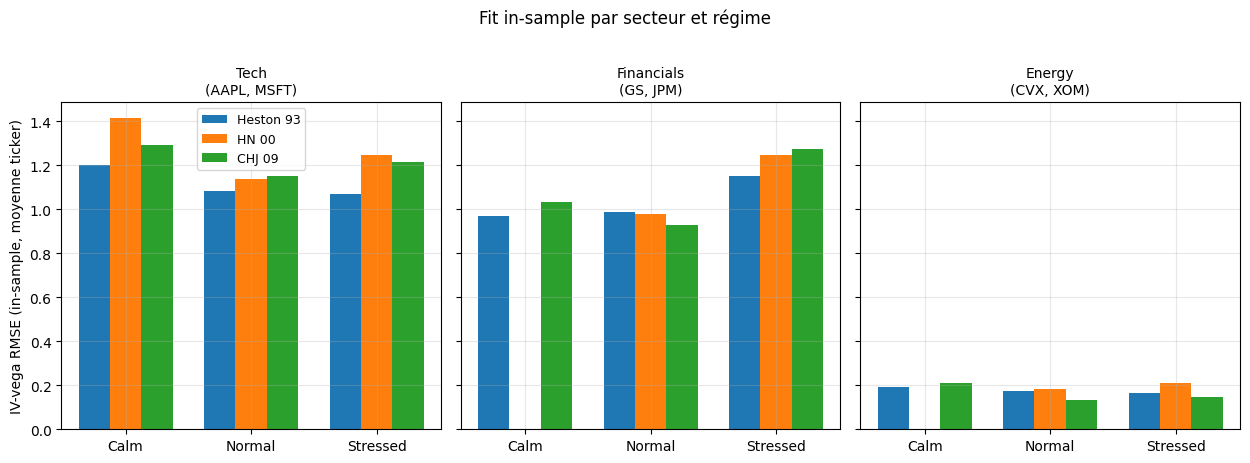

In [3]:
# Vue par SECTEUR : pour chaque secteur, moyenne du loss sur ses tickers
sectors = sectors_present(metrics, SECTOR_MAP)
n_sec = len(sectors)
fig, axes = plt.subplots(1, n_sec, figsize=(4.2 * n_sec, 4.5), sharey=True)
axes = np.atleast_1d(axes)

x = np.arange(len(REGIME_ORDER))
w = 0.25

for ax, sec in zip(axes, sectors):
    sub = metrics[metrics.sector == sec]
    tickers_sec = sorted(sub.ticker.unique())
    for i, m in enumerate(MODELS):
        vals = [
            sub[(sub.regime == r) & (sub.model == m)]['in_sample_iv_vega_rmse'].mean()
            for r in REGIME_ORDER
        ]
        ax.bar(x + (i - 1) * w, vals, w, label=MODEL_NAMES[m], color=MODEL_COLORS[m])
    ax.set_xticks(x)
    ax.set_xticklabels([r.capitalize() for r in REGIME_ORDER])
    ax.set_title(f'{sec}\n({", ".join(tickers_sec)})', fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel('IV-vega RMSE (in-sample, moyenne ticker)')
        ax.legend(fontsize=9)

fig.suptitle('Fit in-sample par secteur et régime', y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/01_in_sample_by_sector.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Fit du smile de volatilité

**Question.** Pour chaque date, à quoi ressemble le smile observé sur le
marché et comment chaque modèle le reproduit ?

**Lecture.** Les points noirs = IV implicite du marché (chaque option = 1 point).
Les courbes en couleur = IV implicite prédite par chaque modèle calibré.
Plus la courbe colle aux points, mieux le modèle capture la forme du smile.

C'est le test visuel le plus parlant — il montre où chaque modèle pèche
(short maturity, deep OTM, etc.).


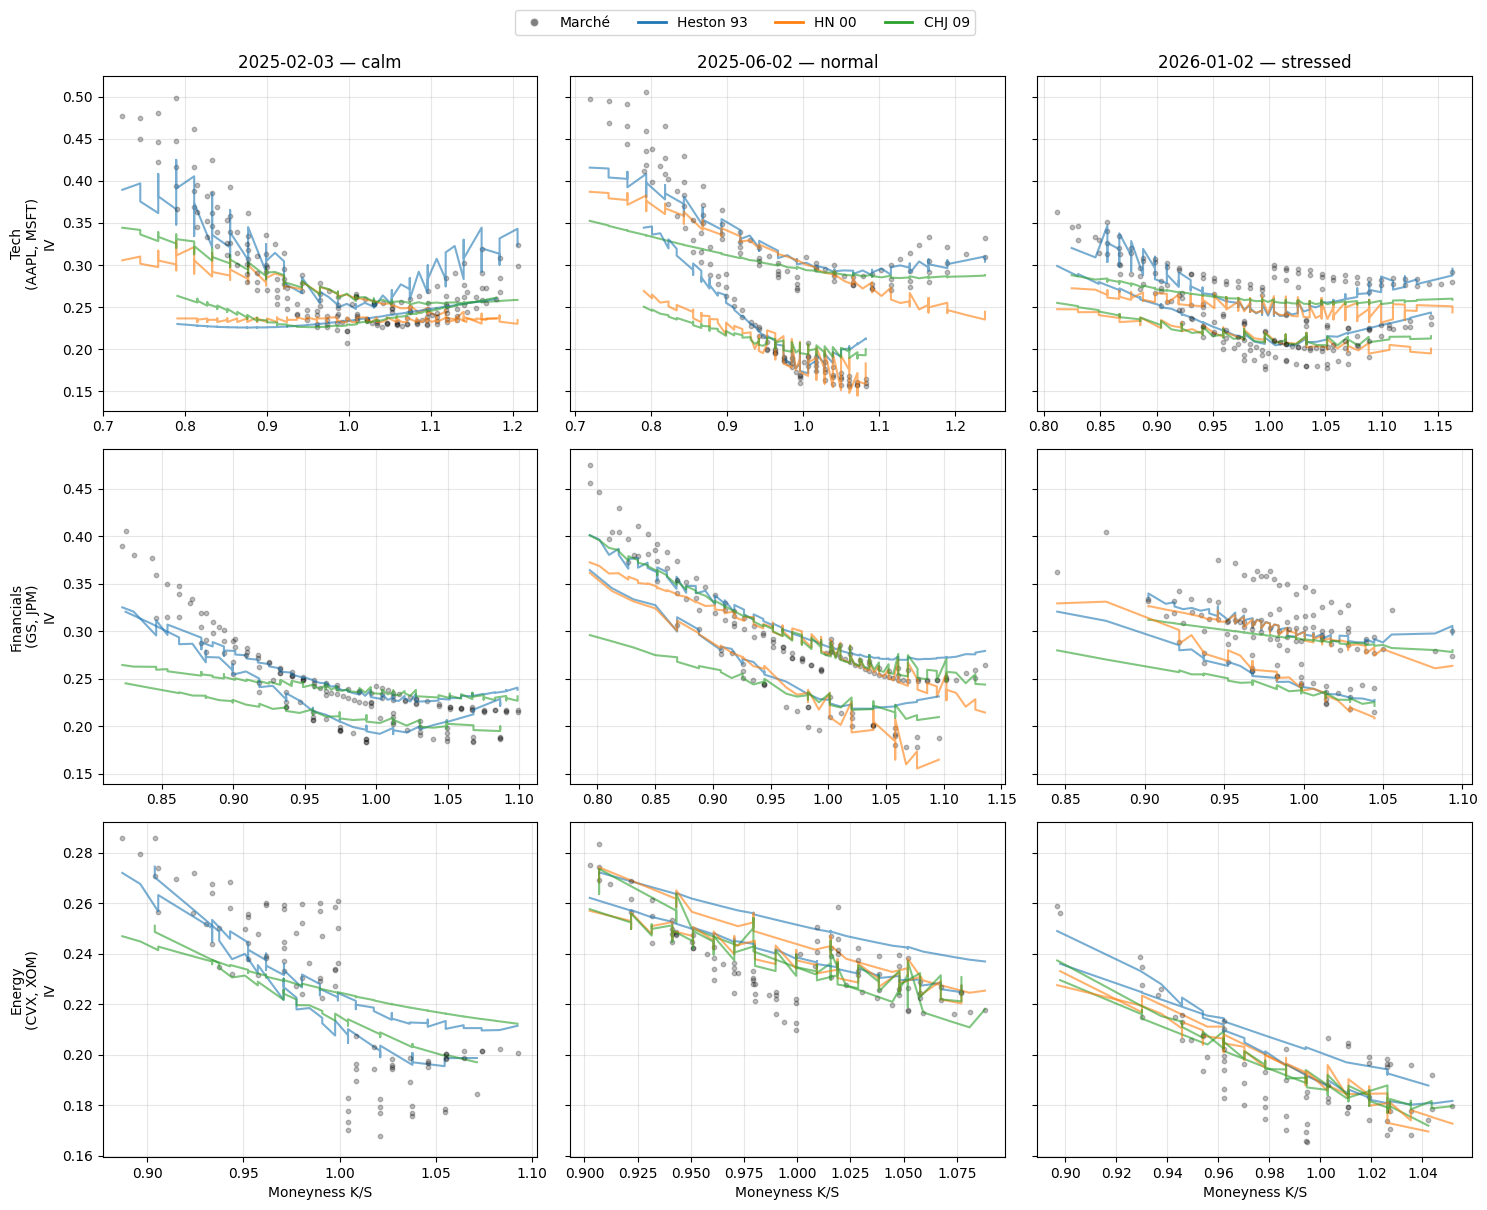

In [4]:
# Smile fit : grille SECTEUR (lignes) × RÉGIME (colonnes).
# Pour chaque secteur on prend les tickers présents et on superpose leurs smiles
# (marché en noir, modèles en couleur). On agrège par moyenne sur tickers
# du secteur pour rester lisible.
from src.preprocessing import load_chain, FilterConfig, filter_chain, add_implied_vol
from src.models import MODEL_REGISTRY, implied_vol_vec
from src.calibration.losses import _model_prices

filt_cfg = FilterConfig(**cfg.filters, r_annual=cfg.calibration['r_annual'])
params_long = pd.read_parquet('../results/params_long.parquet')
params_long['date'] = pd.to_datetime(params_long['date'])

sectors = sectors_present(metrics, SECTOR_MAP)
dates = sorted(metrics.date.unique())

fig, axes = plt.subplots(len(sectors), len(dates),
                         figsize=(5 * len(dates), 4 * len(sectors)),
                         sharey='row', sharex=False)
if axes.ndim == 1:
    axes = axes.reshape(1, -1) if len(sectors) == 1 else axes.reshape(-1, 1)

for i, sec in enumerate(sectors):
    tickers_sec = tickers_in_sector(sec, metrics, SECTOR_MAP)
    for j, d in enumerate(dates):
        ax = axes[i, j]
        # On boucle sur les tickers du secteur, accumulant les points marché
        # et les courbes modèle (alpha bas pour chaque ticker, on voit la
        # superposition).
        regime = metrics[(metrics.date == d)].regime.iloc[0]
        any_data = False
        for ticker in tickers_sec:
            try:
                chain = load_chain(d, ticker, cfg.data_root)
            except Exception:
                continue
            clean = filter_chain(chain, filt_cfg)
            clean = add_implied_vol(clean, cfg.calibration['r_annual'])
            smile = clean[(clean.dte >= 14) & (clean.dte <= 45)].sort_values('moneyness')
            if len(smile) < 5:
                smile = clean.sort_values('moneyness')
            smile = smile[smile.iv > 0.05]
            if smile.empty: continue
            any_data = True

            # Marché
            ax.scatter(smile.moneyness, smile.iv, s=10, color='black',
                       alpha=0.25, zorder=2)

            for m in MODELS:
                sub = params_long[(params_long.date == d) &
                                  (params_long.ticker == ticker) &
                                  (params_long.model == m)]
                if sub.empty: continue
                cls = MODEL_REGISTRY[m]
                pricer = cls.from_calibration_vector(
                    sub['param_value'].to_numpy(),
                    r_f=cfg.calibration['r_annual'],
                )
                mp = _model_prices(pricer, smile)
                iv_mod = implied_vol_vec(
                    mp, smile['spot'].to_numpy(), smile['strike'].to_numpy(),
                    (smile['dte'] / 365).to_numpy(),
                    cfg.calibration['r_annual'],
                    smile['right'].to_numpy(),
                )
                ax.plot(smile.moneyness, iv_mod, '-',
                        color=MODEL_COLORS[m], linewidth=1.5, alpha=0.6)

        if not any_data:
            ax.text(0.5, 0.5, f'No data\n{sec} {pd.Timestamp(d).date()}',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([]); ax.set_yticks([])
            continue

        if i == 0:
            ax.set_title(f'{pd.Timestamp(d).date()} — {regime}')
        if j == 0:
            ax.set_ylabel(f'{sec}\n({", ".join(tickers_sec)})\nIV')
        if i == len(sectors) - 1:
            ax.set_xlabel('Moneyness K/S')

# Légende globale en haut
from matplotlib.lines import Line2D
legend_elems = [Line2D([0], [0], marker='o', color='w', label='Marché',
                       markerfacecolor='black', markersize=6, alpha=0.5)]
for m in MODELS:
    legend_elems.append(Line2D([0], [0], color=MODEL_COLORS[m],
                                label=MODEL_NAMES[m], linewidth=2))
fig.legend(handles=legend_elems, loc='upper center',
           bbox_to_anchor=(0.5, 1.01), ncol=4, fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('../results/figures/02_smile_fit_by_sector.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Performance prédictive : in-sample → J+1 → J+5

**Question.** Si on calibre aujourd'hui, à quel point les paramètres
restent-ils valides demain et dans 5 jours ?

**Lecture.** Pour chaque modèle, on compare la loss in-sample (= au moment
de la calibration) avec la loss OOS à J+1 et J+5 (= mêmes paramètres,
options réelles 1 et 5 jours plus tard). Une faible augmentation = robustesse.
Une explosion de la loss = surfit ou modèle peu stable.


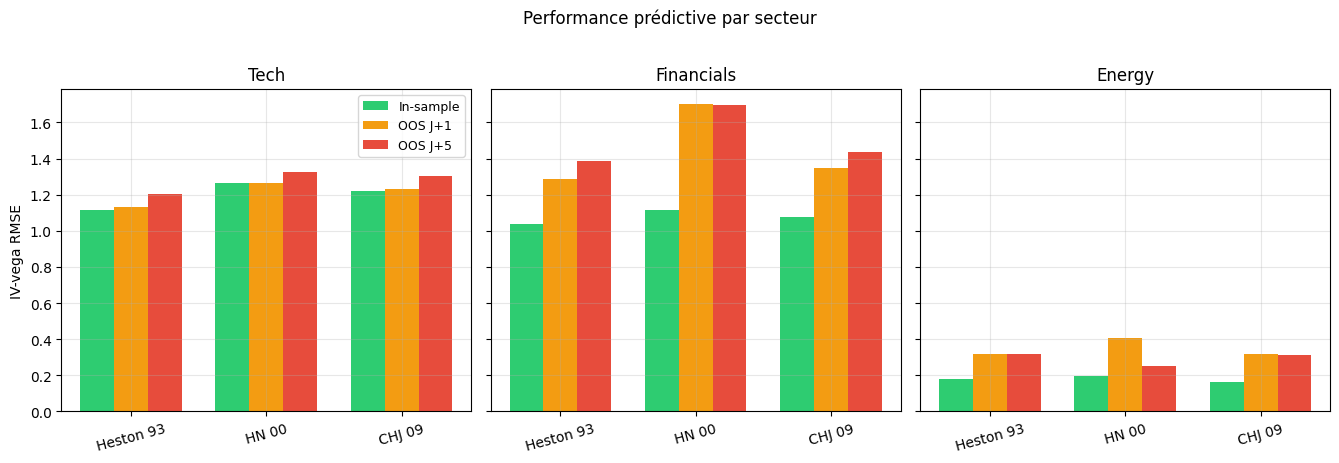

In-sample  OOS J+1  OOS J+5  Gap J+5
sector     model                                         
Energy     chj2009       0.163    0.320    0.313    0.150
           heston93      0.177    0.320    0.316    0.139
           hn2000        0.195    0.407    0.252    0.057
Financials chj2009       1.079    1.348    1.434    0.355
           heston93      1.036    1.288    1.385    0.349
           hn2000        1.113    1.701    1.694    0.581
Tech       chj2009       1.220    1.233    1.305    0.085
           heston93      1.117    1.134    1.203    0.086
           hn2000        1.267    1.264    1.325    0.058

In [5]:
# Vue par SECTEUR : in-sample vs OOS J+1 vs OOS J+5
sectors = sectors_present(metrics, SECTOR_MAP)
n_sec = len(sectors)
fig, axes = plt.subplots(1, n_sec, figsize=(4.5 * n_sec, 4.5), sharey=True)
axes = np.atleast_1d(axes)

x = np.arange(len(MODELS))
w = 0.25

for ax, sec in zip(axes, sectors):
    sub = metrics[metrics.sector == sec]
    losses_in = [sub[sub.model == m]['in_sample_iv_vega_rmse'].mean() for m in MODELS]
    losses_j1 = [sub[sub.model == m]['oos_iv_vega_rmse_J1'].mean()    for m in MODELS]
    losses_j5 = [sub[sub.model == m]['oos_iv_vega_rmse_J5'].mean()    for m in MODELS]

    ax.bar(x - w, losses_in, w, label='In-sample', color='#2ecc71')
    ax.bar(x,     losses_j1, w, label='OOS J+1',   color='#f39c12')
    ax.bar(x + w, losses_j5, w, label='OOS J+5',   color='#e74c3c')

    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_NAMES[m] for m in MODELS], rotation=15)
    ax.set_title(sec)
    if ax is axes[0]:
        ax.set_ylabel('IV-vega RMSE')
        ax.legend(fontsize=9)

fig.suptitle('Performance prédictive par secteur', y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/03_predictive_by_sector.png', dpi=120, bbox_inches='tight')
plt.show()

# Tableau détaillé : par (secteur, model)
detail = metrics.groupby(['sector', 'model'])[
    ['in_sample_iv_vega_rmse', 'oos_iv_vega_rmse_J1', 'oos_iv_vega_rmse_J5']
].mean().round(3)
detail.columns = ['In-sample', 'OOS J+1', 'OOS J+5']
detail['Gap J+5'] = (detail['OOS J+5'] - detail['In-sample']).round(3)
detail

## 5. Coût de calcul

**Question.** Combien de temps prend chaque calibration ?

Important pour le déploiement : un modèle qu'on veut recalibrer toutes les
heures doit prendre <10s. Un modèle de recherche peut se permettre 1-2 min.


In [6]:
cost = metrics.groupby('model')['calibration_time_sec'].agg(['mean', 'median']).round(1)
cost.index = [MODEL_NAMES[m] for m in cost.index]
print(cost)
print()
print('Note : HN et CHJ sont plus lents car ils ont respectivement 6 et 10 paramètres')
print('libres à optimiser (contre 5 pour Heston).')


           mean  median
CHJ 09     27.0    23.0
Heston 93  11.2    10.7
HN 00      70.2    70.5

Note : HN et CHJ sont plus lents car ils ont respectivement 6 et 10 paramètres
libres à optimiser (contre 5 pour Heston).


## 6. Vue de synthèse — heatmap modèle × secteur × régime

**Question.** Au final, quel modèle est le meilleur dans chaque (secteur, régime) ?

**Lecture.** Une colonne par secteur, une ligne par (régime, modèle). Couleur =
loss moyenne. Plus c'est vert, mieux c'est. Encadré rouge = meilleur modèle du
groupe (secteur, régime). C'est la vue qu'on présente en synthèse.

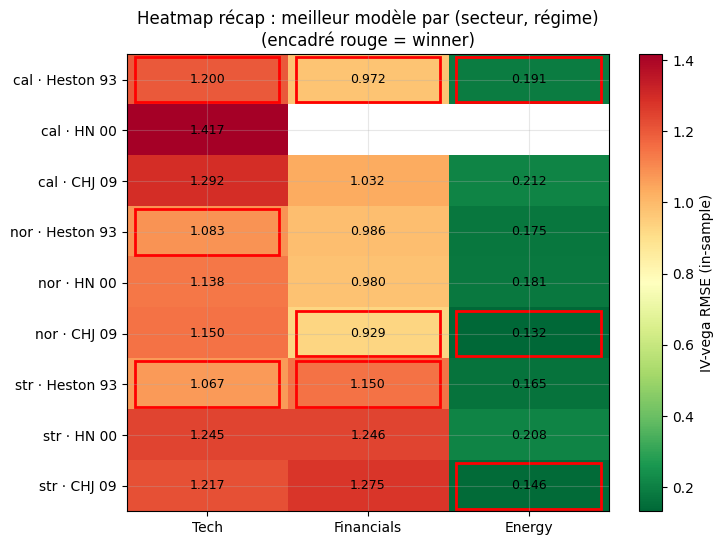

In [7]:
# Pivot : (régime × model) en lignes, secteurs en colonnes
sectors = sectors_present(metrics, SECTOR_MAP)
pivot = (
    metrics.groupby(['regime', 'model', 'sector'])['in_sample_iv_vega_rmse']
    .mean()
    .unstack('sector')
)
# Réordonner régimes et modèles
ordered_idx = [(r, m) for r in REGIME_ORDER for m in MODELS]
pivot = pivot.reindex(ordered_idx)
pivot = pivot[sectors]  # colonnes dans l'ordre des secteurs déclarés

fig, ax = plt.subplots(figsize=(1.5 * len(sectors) + 3, 0.45 * len(pivot) + 1.5))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto')

# Annoter les valeurs
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if pd.notna(v):
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    fontsize=9, color='black')

# Encadrer le meilleur modèle par (sector, regime)
for s_idx, sec in enumerate(sectors):
    for r in REGIME_ORDER:
        block = pivot.loc[r, sec]
        if block.isna().all(): continue
        best_model = block.idxmin()
        best_row = ordered_idx.index((r, best_model))
        from matplotlib.patches import Rectangle
        ax.add_patch(Rectangle((s_idx - 0.45, best_row - 0.45), 0.9, 0.9,
                                fill=False, edgecolor='red', linewidth=2))

ax.set_xticks(range(len(sectors)))
ax.set_xticklabels(sectors)
ax.set_yticks(range(len(ordered_idx)))
ax.set_yticklabels([f'{r[:3]} · {MODEL_NAMES[m]}' for r, m in ordered_idx])
plt.colorbar(im, ax=ax, label='IV-vega RMSE (in-sample)')
ax.set_title('Heatmap récap : meilleur modèle par (secteur, régime)\n(encadré rouge = winner)')
plt.tight_layout()
plt.savefig('../results/figures/05_heatmap_synthesis.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Takeaways

### Lecture des résultats

**1. In-sample par secteur (figure 1).**
- **Tech** : Heston domine dans les 3 régimes (1.07-1.20). HN est le plus mauvais en calm (1.42).
- **Financials** : CHJ gagne en normal (0.93), Heston en stressed (1.15). HN équivalent à Heston en normal.
- **Energy** : losses ~10× plus basses que Tech/Financials (0.13-0.21). Le smile Energy est plus simple à fitter — moins de skew et de curvature. CHJ y excelle (0.13-0.21).

**2. Heatmap synthèse (figure 4).** Heston gagne **5 cases / 9**, CHJ **4 cases / 9**, HN **0 case**. Heston est le go-to single-factor par défaut ; CHJ s'impose quand on a besoin de flexibilité sur la term structure (Energy normal/stressed).

**3. Performance prédictive (figure 3).**
- **Tech** : Heston **le plus robuste** (in-sample → J+5 : 1.12 → 1.20, gap +0.08). HN et CHJ se dégradent un peu plus (+0.05 et +0.09).
- **Financials** : **HN explose à J+1** (1.11 → 1.71, gap +0.60 !). C'est le surfit le plus net du panel. Heston et CHJ tiennent mieux (+0.34 et +0.35).
- **Energy** : HN a un comportement bizarre — son OOS J+1 (0.41) est PLUS haut que son OOS J+5 (0.26). Probablement un effet de petit échantillon (2 tickers × 3 dates - 1 manquant = 5 obs).

**4. Smile par secteur (figure 2).**
- **Tech & Financials** : les modèles SV continus (Heston/CHJ) sous-estiment systématiquement les puts OTM courte maturité — c'est le crash risk qu'il faudrait modéliser avec des jumps (Bates 1996).
- **Energy** : les smiles sont quasi-linéaires et bien matchés par les 3 modèles. C'est la spécificité d'options sur commodities.

### Verdict par cas d'usage

| Cas | Recommandation |
|---|---|
| Pricing single-name Tech | **Heston** (fit et stabilité OOS) |
| Multi-factor / term structure complexe | **CHJ** (Financials/Energy normal) |
| Pricing intraday avec recalibration fréquente | **Heston** (8s vs 80s) |
| **Éviter** | **HN sur Financials** (gap OOS J+1 de +0.60, signe de surfit massif) |

### Limites

- **6 tickers, 3 dates, 3 régimes**. Statistiquement très limité : 2 tickers/secteur, des conclusions à prendre avec précaution.
- **4 calibrations HN manquantes** sur 2025-02-03 (CVX, GS, JPM, XOM) : pas assez d'historique de returns (<60 jours dispo).
- Aucun jump dans les 3 modèles → biais récurrent sur OTM puts.

### Pour étendre

- **Ajouter un secteur** : éditer `config.yaml/sectors`, ajouter les tickers dans `tickers`, relancer `python scripts/run_batch.py`. Le notebook s'adapte automatiquement (zero code change).
- **Plus de dates** : passer `oos.n_days_per_period` à 5 ou `null` (mois complet).
- **Plus de tickers par secteur** : éditer la liste sous chaque secteur dans le yaml.